# Import thư viện

In [1]:
import cv2
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# from sklearn.decomposition import PCA
# from sklearn.manifold import TSNE
# from skimage.metrics import structural_similarity as ssim
# from scipy.stats import ks_2samp

In [2]:
utils_path = os.path.abspath(os.path.join(os.getcwd(), "../..", "src"))

if utils_path not in sys.path:
    sys.path.append(utils_path)

from utils import *

In [3]:
CSV_PATH = "../../data/Image/labels.csv"
CSV_REMOVE_DUPLICATE_PATH = "../../data/Image/labels_remove_duplicate.csv"

IMAGES_PATH = "../../data/Image/images"
IMAGES_REMOVE_DUPLICATE_PATH = "../../data/Image/images_remove_duplicate"

PIXEL_RANGE = 256
SAMPLE_SIZE = 100

np.random.seed(42)

# Load data

In [4]:
data = pd.read_csv(CSV_PATH)

In [5]:
data.head()

,image,label,original_image
0,img_00001.jpg,Tomato___Bacterial_spot,bcffc5ba-6602-455f-a84c-eb0ad85672bc___UF.GRC_...
1,img_00002.jpg,Tomato___Bacterial_spot,2f3e2c44-a83b-4f72-a831-ac42aec1020e___UF.GRC_...
2,img_00003.jpg,Tomato___healthy,0c4b06d5-4053-44fc-99b6-504934fdd3a9___GH_HL L...
3,img_00004.jpg,Tomato___Leaf_Mold,ebe5c5c5-7e29-4aa7-bc0b-f895b5bc3d20___Crnl_L....
4,img_00005.jpg,Tomato___Leaf_Mold,bc374eed-3802-4ffe-9339-47e04a74a648___Crnl_L....


In [6]:
data.drop("original_image", axis=1).describe()

,image,label
count,6000,6000
unique,6000,5
top,img_00001.jpg,Tomato___healthy
freq,1,1249


## Kiểm tra số lượng class

In [7]:
# labels = [label.removeprefix("Tomato___") for label in data["label"].unique()]
labels = [label for label in data["label"].unique()]
print(labels)

['Tomato___Bacterial_spot', 'Tomato___healthy', 'Tomato___Leaf_Mold', 'Tomato___Early_blight', 'Tomato___Late_blight']


## Load ảnh

In [8]:
n_images = 0

all_images = []

images = {label: [] for label in labels}

for row in data.itertuples(index=False):
    img_name = row[0]
    img_label = row[1]
    img_path = os.path.join(IMAGES_PATH, img_name)
    img = cv2.imread(img_path, cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    images[img_label].append(img)

    all_images.append(img)
    n_images += 1

for label in labels:
    images[label] = np.array(images[label])

all_images = np.array(all_images)

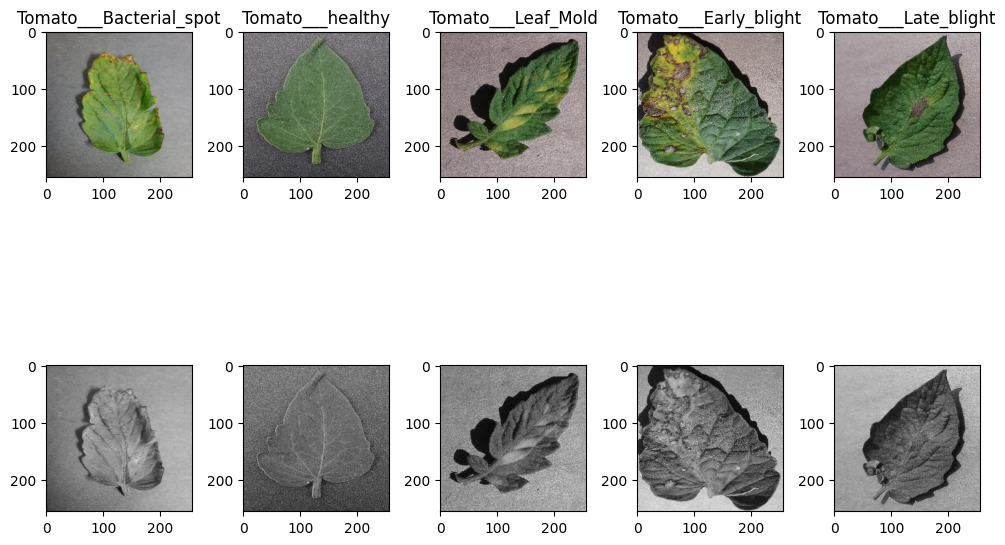

In [9]:
fig, ax = plt.subplots(2, 5, figsize=(10, 8))

for index, label in enumerate(labels):
    img = images[label][0]

    ax[0][index % 5].imshow(img)
    ax[0][index % 5].set_title(label)

    # Gray
    ax[1][index % 5].imshow(cv2.cvtColor(img, cv2.COLOR_RGB2GRAY), cmap="gray")
plt.tight_layout()

# 2.1.2. Phân tích thống kê tập dữ liệu

## a) Trực quan hoá phân phối giá trị pixel trên toàn tập

Với tập dữ liệu (6000, 256, 256, 3), tổng số pixel cần xử lý là 6000 x 256 x 256 = 393_216_000 (393 triệu). Phân tích thống kê trên toàn tập dữ liệu là không khả thi, do đó thực hiện việc lấy mẫu như sau:

Lấy 100 mẫu, kích thước tập mẫu là (100, 256, 256, 3), tổng số pixel cần xử lý là 6_553_600 (6.5 triệu) x 3 kênh màu, bộ nhớ cần thiết là 

In [10]:
sample_id = np.random.randint(0, len(all_images), size=SAMPLE_SIZE)
samples = all_images[sample_id]

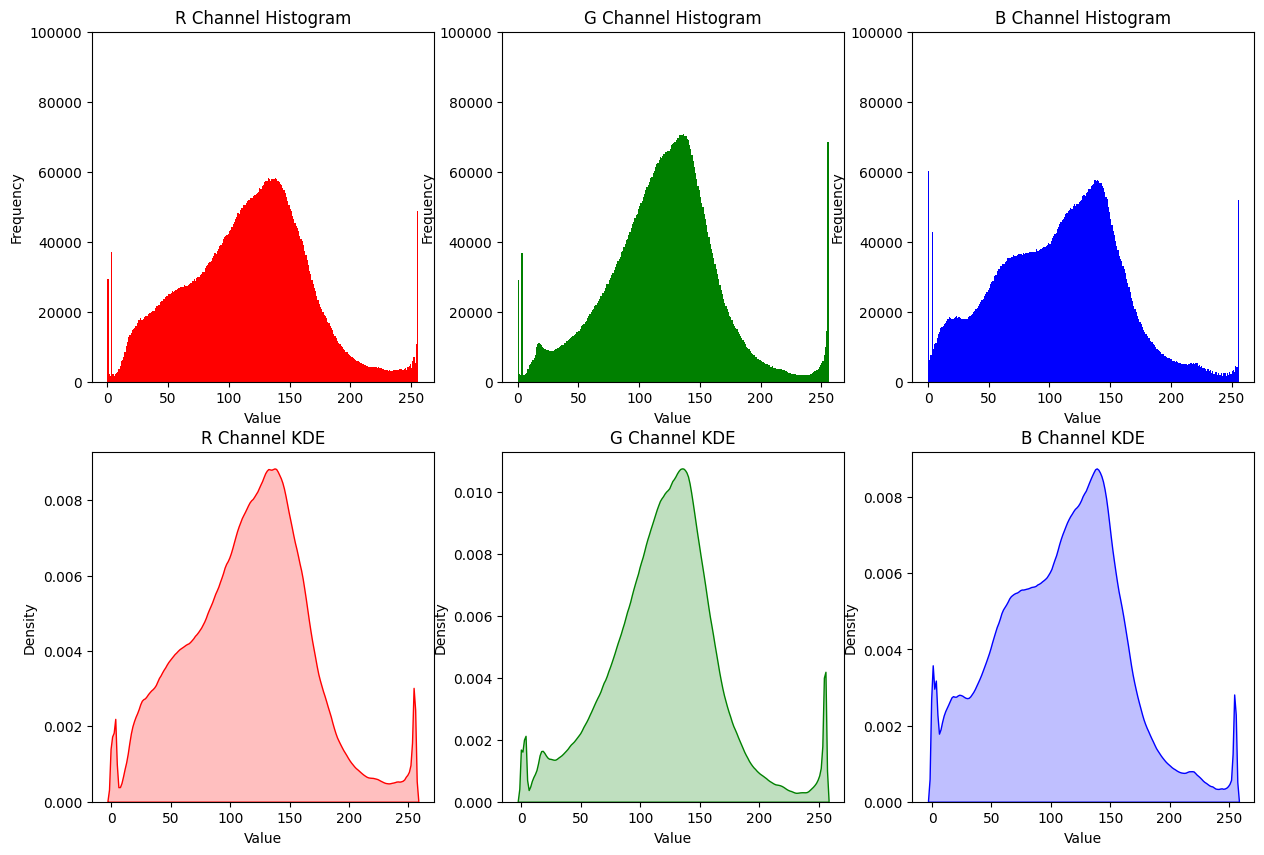

In [11]:
fig, ax = plt.subplots(2, 3, figsize=(15, 10))

visualize_histogram_subp(samples[:, :, :, 0].flatten(), PIXEL_RANGE, (0, PIXEL_RANGE), ax[0][0], "R Channel Histogram", "red", 100_000)
visualize_histogram_subp(samples[:, :, :, 1].flatten(), PIXEL_RANGE, (0, PIXEL_RANGE), ax[0][1], "G Channel Histogram", "green", 100_000)
visualize_histogram_subp(samples[:, :, :, 2].flatten(), PIXEL_RANGE, (0, PIXEL_RANGE), ax[0][2], "B Channel Histogram", "blue", 100_000)

visualize_kde_subp(samples[:, :, :, 0].flatten(), ax[1][0], "R Channel KDE", 0.5, "red")
visualize_kde_subp(samples[:, :, :, 1].flatten(), ax[1][1], "G Channel KDE", 0.5, "green")
visualize_kde_subp(samples[:, :, :, 2].flatten(), ax[1][2], "B Channel KDE", 0.5, "blue")

In [12]:
del samples

## b) Phân tích tỉ lệ các lớp

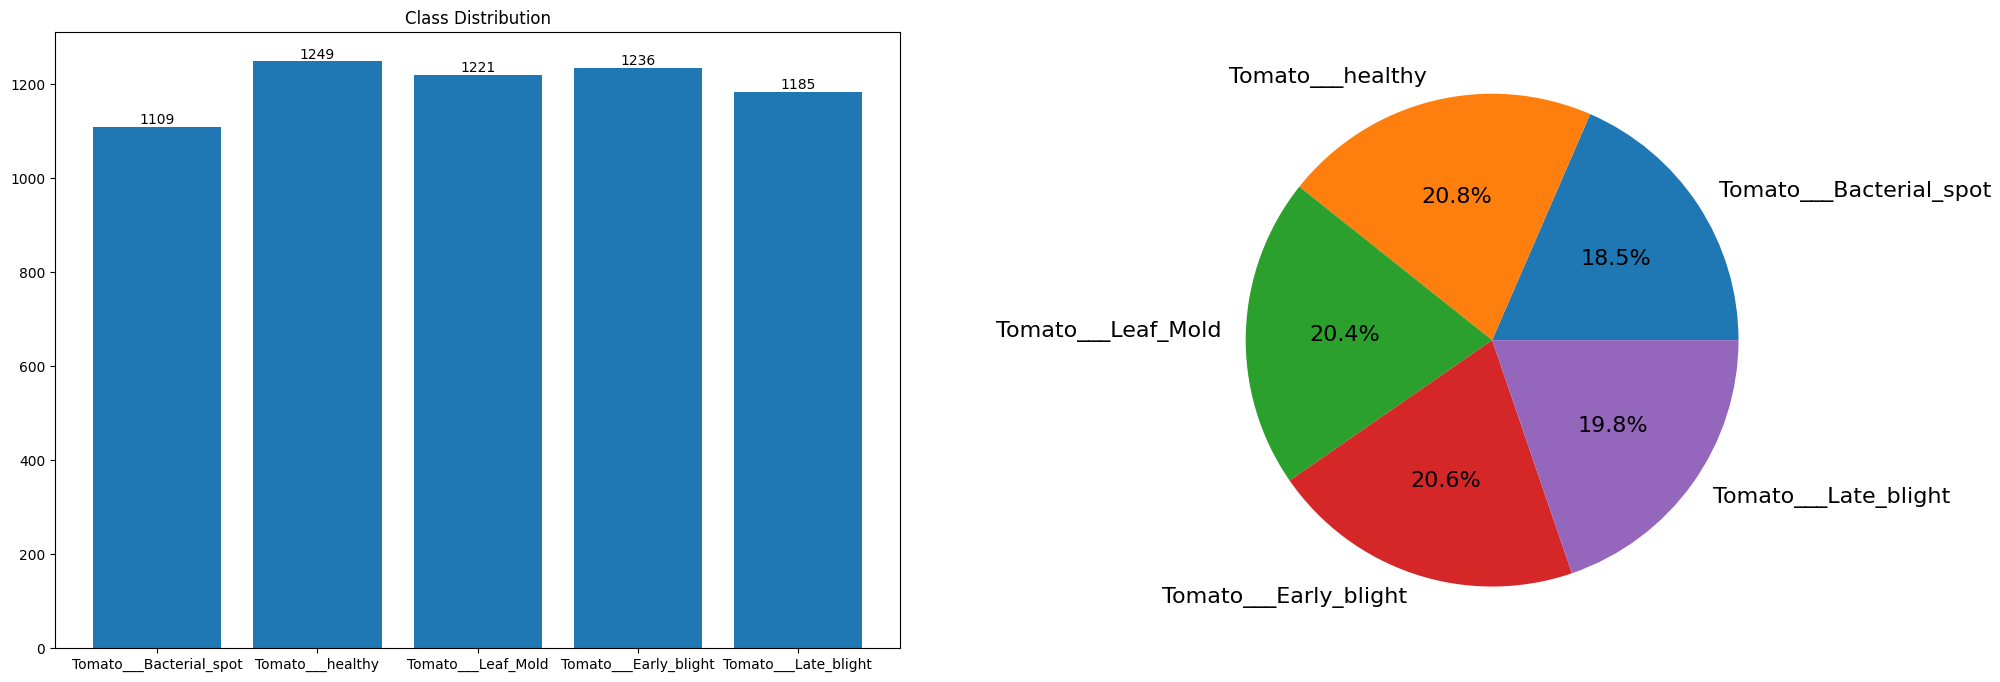

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(24, 8))

barplot = ax[0].bar(labels, [len(images[label]) for label in labels])
ax[0].bar_label(barplot, labels=[len(images[label]) for label in labels], label_type="edge")
ax[0].set_title("Class Distribution")

pieplot = ax[1].pie([len(images[label]) for label in labels], labels=list(images.keys()), autopct="%1.1f%%", textprops={"fontsize": 16})

Với toàn bộ tập dữ liệu là 6000 mẫu, các class được phân bố tương đối đồng đều. Mỗi class chiếm khoảng 19-21% tập dữ liệu và không có sự chênh lệch đáng kể giữa các class

In [14]:
min_class = None
min_len = 0

for label in labels:
    if min_class is None:
        min_class = label
        min_len = len(images[label])
    else:
        if min_len > len(images[label]):
            min_class = label
            min_len = len(images[label])

print(f"Class có ít mẫu nhất là: {min_class} với {min_len} mẫu")
for label in labels:
    if label == min_class:
        continue
    ratio = len(images[label]) / min_len
    print(f"Tỉ lệ mẫu của {label} so với {min_class} là: {round(ratio, 2)}")

Class có ít mẫu nhất là: Tomato___Bacterial_spot với 1109 mẫu
Tỉ lệ mẫu của Tomato___healthy so với Tomato___Bacterial_spot là: 1.13
Tỉ lệ mẫu của Tomato___Leaf_Mold so với Tomato___Bacterial_spot là: 1.1
Tỉ lệ mẫu của Tomato___Early_blight so với Tomato___Bacterial_spot là: 1.11
Tỉ lệ mẫu của Tomato___Late_blight so với Tomato___Bacterial_spot là: 1.07


## c) Xử lý ảnh trùng lặp

In [9]:
# sử dụng union set để tối ưu
def find(parent, x):
    if parent[x] != x:
        parent[x] = find(parent, parent[x])

    return parent[x]

def union(parent, a, b):
    rootA = find(parent, a)
    rootB = find(parent, b)
    if rootA != rootB:
        parent[rootB] = rootA

In [10]:
def calculate_hashes(images: np.ndarray):
    hasher = cv2.img_hash.PHash_create()

    hashes = []

    for image in images:
        h = hasher.compute(image)
        hashes.append(h)

    return hashes

In [12]:
def cluster_hashes(hashes, threshold: int=8):
    hasher = cv2.img_hash.PHash_create()

    N = len(hashes)
    parent = list(range(N))

    for i in range(N):
        for j in range(i + 1, N):
            dist = hasher.compare(hashes[i], hashes[j])
            if dist <= threshold:
                union(parent, i, j)

    clusters = {}
    for i in range(N):
        root = find(parent, i)
        clusters.setdefault(root, []).append(i)

    return list(clusters.values())

In [13]:
def report(clusters, total_count: int):
    duplicate_count = sum(len(c) - 1 for c in clusters if len(c) > 1)

    duplicate_ratio = duplicate_count / total_count

    print(f"Total: {total_count}")
    print(f"Cluster: {len(clusters)}")
    print(f"Duplicate: {duplicate_count}")
    print(f"Ratio: {duplicate_ratio:.3f}")

    return duplicate_count, duplicate_ratio

In [14]:
def remove_duplicates(clusters):
    images_to_keep = []
    images_to_remove = []

    for cluster in clusters:
        images_to_keep.append(cluster[0])   # giữ ảnh đầu
        images_to_remove.extend(cluster[1:])

    # if delete:
        # pass

    return images_to_keep, images_to_remove

In [15]:
hashes = calculate_hashes(all_images)

clusters = cluster_hashes(hashes, threshold=6)

report(clusters, n_images)

keep, remove = remove_duplicates(clusters)

print(f"Keep: {len(keep)}")
print(f"Remove: {len(remove)}")

Total: 6000
Cluster: 5908
Duplicate: 92
Ratio: 0.015
Keep: 5908
Remove: 92


Thực nghiệm chọn ngưỡng bằng 6 cho thấy loại bỏ được ảnh trùng, với ngưỡng cao hơn 6, tồn tại nhiều ảnh khác nhau nhưng được đánh giá là trùng nhau

In [ ]:
for cluster in clusters:
    if len(cluster) > 1:
        fig, ax = plt.subplots(1, len(cluster))
        for i in range(len(cluster)):
            ax[i].imshow(all_images[cluster[i]])

In [16]:
remove

[2052,
 3030,
 198,
 257,
 429,
 532,
 675,
 787,
 898,
 1308,
 1573,
 2139,
 2146,
 2486,
 2540,
 2612,
 2866,
 2936,
 3218,
 3472,
 3693,
 3796,
 3827,
 3959,
 4103,
 4114,
 4128,
 4193,
 4258,
 4314,
 4399,
 4465,
 4630,
 4731,
 4851,
 5090,
 5426,
 5651,
 1298,
 4132,
 5310,
 3396,
 2395,
 2919,
 1459,
 4295,
 5042,
 4504,
 2725,
 1941,
 2013,
 5846,
 2275,
 4108,
 5916,
 2822,
 4876,
 2805,
 5450,
 5580,
 5769,
 2744,
 4892,
 5098,
 4029,
 5436,
 2938,
 5753,
 2912,
 1934,
 4951,
 2131,
 3628,
 4935,
 5998,
 3201,
 2452,
 2875,
 5103,
 3078,
 5511,
 3745,
 4337,
 4683,
 3008,
 5748,
 4901,
 4583,
 5952,
 5591,
 4348,
 5797]

Lưu tập dữ liệu đã loại bỏ trùng lặp

In [17]:
if not(os.path.exists(IMAGES_REMOVE_DUPLICATE_PATH)):
    os.makedirs(IMAGES_REMOVE_DUPLICATE_PATH)

In [18]:
# labels_remove_duplicate.csv
df = data.iloc[keep]
df.to_csv(CSV_REMOVE_DUPLICATE_PATH, index=False)

In [19]:
# images_remove_duplicate
for id in keep:
    img_name = data.iloc[id]["image"]
    img = all_images[id]
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    img_path = os.path.join(IMAGES_REMOVE_DUPLICATE_PATH, img_name)
    cv2.imwrite(img_path, img)

## d) Phân tích độ tương phản và độ sáng toàn cục

Với tập dữ liệu (6000, 256, 256, 3), tổng số pixel cần xử lý là 6000 x 256 x 256 = 393_216_000 (393 triệu). Phân tích độ sáng trên toàn tập dữ liệu là không khả thi, do đó thực hiện việc lấy mẫu và chuyển đổi về ảnh xám như sau:

Lấy 100 mẫu mỗi class, kích thước tập mẫu là (500, 256, 256, 3), sau đó chuyển đổi ảnh RGB thành ảnh xám theo công thức:

g = 0.299 * r + 0.587 * g + 0.114 * b

Tổng số pixel cần xử lý là 32_768_000 (32.7 triệu) x 1 kênh màu.

In [25]:
sample_gray = dict()

for label in labels:
    sample_id = np.random.randint(0, len(images[label]), size=SAMPLE_SIZE)
    sample = images[label][sample_id]
    sample_gray[label] = convert_rgb_to_color_space(sample, "gray")

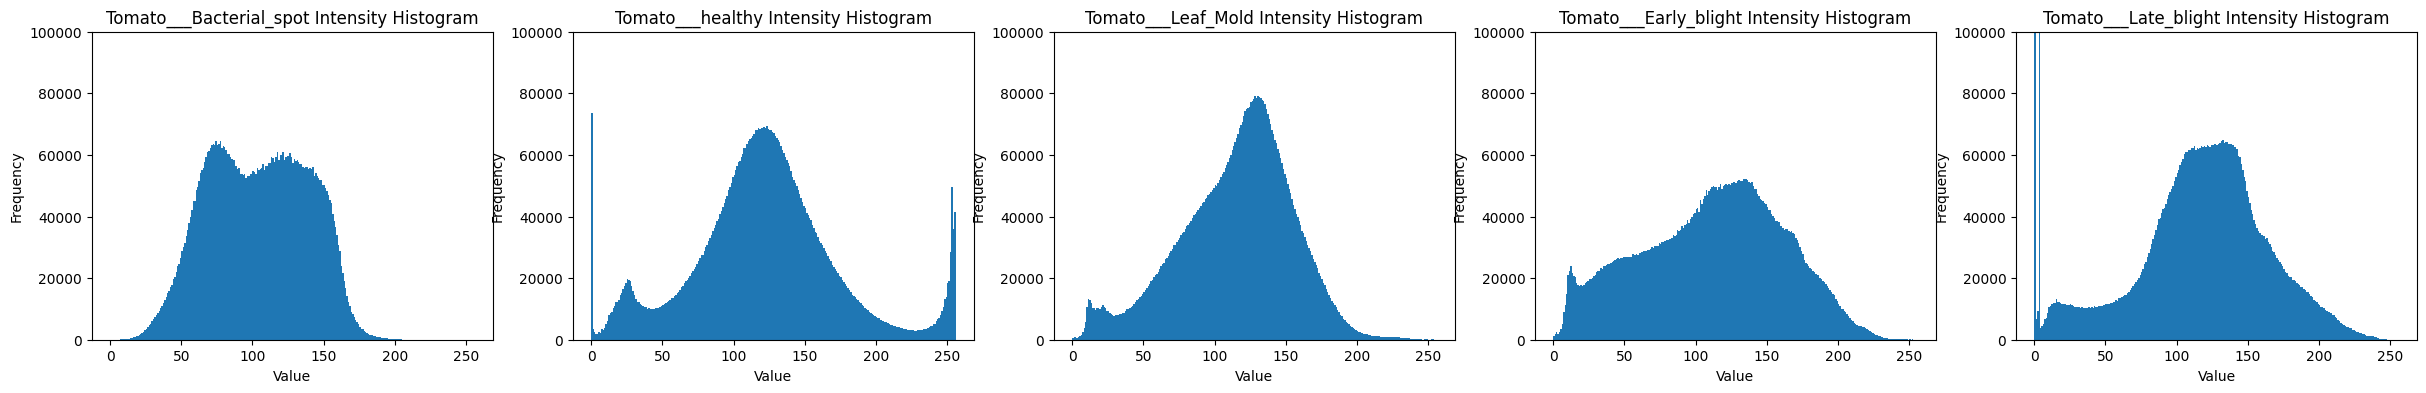

In [26]:
fig, ax = plt.subplots(1, len(labels), figsize=(30, 4))

for index, label in enumerate(labels):
    visualize_histogram_subp(sample_gray[label].flatten(), PIXEL_RANGE, (0, PIXEL_RANGE), ax[index], label + " Intensity Histogram", ylim=100_000)

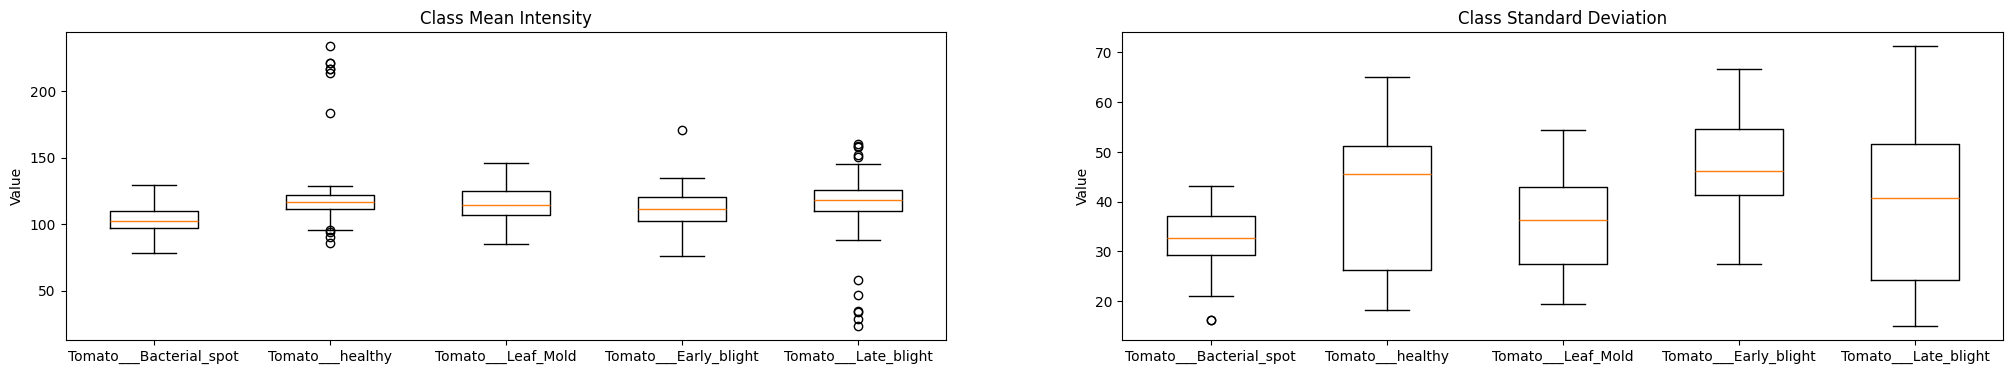

In [27]:
sample_gray_mean = dict()
sample_gray_std = dict()

for label in labels:
    _mean = np.mean(sample_gray[label], axis=(1, 2))
    _std = np.std(sample_gray[label], axis=(1, 2))
    sample_gray_mean[label] = _mean
    sample_gray_std[label] = _std

fig, ax = plt.subplots(1, 2, figsize=(25, 4))

ax[0].boxplot([sample_gray_mean[label].flatten() for label in labels])
ax[0].set_title("Class Mean Intensity")
ax[0].set_ylabel("Value")
ax[0].set_xticks(range(1, len(labels) + 1), labels)

ax[1].boxplot([sample_gray_std[label].flatten() for label in labels])
ax[1].set_title("Class Standard Deviation")
ax[1].set_ylabel("Value")
ax[1].set_xticks(range(1, len(labels) + 1), labels)